In [4]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

### 1. Import Database / data

In [6]:
conn = sqlite3.connect('customer_churn.db')  #first we have made the connection with the database

sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table'
"""
# the above sql query is used to read the table name using sqlite_master

tables = pd.read_sql(sql_query, conn)   #here we are reading the table using pandas and store it in variable

#create dataframe using pandas for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [7]:
#print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    #Get columns information
    columns_query = f"PRAGMA table_info({table_name});"    #PRAGMA is a special method in sqlite that helps in to retive the table info or schema of the table
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

#Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [8]:
df_db_customer.head()
# also we can check the tail of the database using df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [9]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [10]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


### 2. Data Cleaning

In [11]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [12]:
# a. rename column - name to customername
# b. drop columns - interest and pincode
# c. change data type of dob from object to date
# d. data standardization - gender
# e. fix missing values - country

In [13]:
# a. rename column - name to customername

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [14]:
# b. drop columns - interest and pincode

df_db_customer.columns[-2:]


Index(['interests', 'pincode'], dtype='object')

In [15]:
df_db_customer.columns[6:]

Index(['interests', 'pincode'], dtype='object')

In [16]:
df_db_customer.drop(df_db_customer.columns[-2:], axis =1, inplace = True)   #we can also delete by specifying the names of the column and to delete the entire column we set axis =1 or to delete row set axis=0
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [17]:
# c. change data type of dob from object to date

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])    #instead of using inplace to save the changes we can also use the name of database to save the changes made
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [18]:
# d. data standardization - gender

df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [19]:
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [20]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [21]:
# e. fix missing values - country

df_db_customer['country'].isna()

0     False
1     False
2     False
3     False
4     False
5      True
6     False
7     False
8      True
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
Name: country, dtype: bool

In [22]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [23]:
df_db_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [24]:
# make country and state - unique value pair

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
state_country_mapping

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Uttar Pradesh': 'India',
 'Telangana': 'India'}

In [25]:
#Fill the Null value using the mapping we have created earlier

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))
df_db_customer['country']

0     India
1     India
2     India
3     India
4     India
5     India
6     India
7     India
8     Nepal
9     Nepal
10    India
11    India
12    India
13    India
14    India
15    India
16    India
17    India
18    India
19    India
20    India
Name: country, dtype: object

In [26]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [27]:
df_db_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [28]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [29]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [30]:
#to apply date time data type to mutliple columns
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [31]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [32]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [33]:
# removing the col_1 and comment column
df_db_support.drop(columns=['col_1', 'comment'], axis =1, inplace = True)

In [34]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [35]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


# Feature Engineering


##### Feature Engineering means to use the existing columns, update them, using thoes column to make new values

In [36]:
#First we will make churn flag

In [37]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [38]:
#create a new column using existing col - churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [39]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [40]:
# merging the tables using the customerid using left join using df_db_subscription as it cointains the main data
df_db_subscription.merge(df_db_customer, on = 'customerid', how = 'left')

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,41,0,arjun,Nepal,Kathmandu,Male,1993-10-29


In [41]:
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN


In [42]:
df.shape

(23, 20)

In [43]:
df_db_subscription.shape
#as we can se the main table has only 21 columns and we are performing left join on that table so the resultant table cannot exceed from this table
#there can be duplicate record in the final table

(21, 12)

In [44]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [45]:
#to check the no of unique values
df_db_subscription['customerid'].nunique()

21

In [46]:
df_db_customer['customerid'].nunique()

21

In [47]:
df_db_support['customerid'].nunique()

7

In [48]:
df_db_support['customerid'].size
#we can se this table contains 7 unique values but has total size 9 thats why the extra 2 value are getting added to the final dataset

9

In [49]:
df_db_support.head()
#as we can see in this table that whenever the customer complains the customerid is stored again so it has duplicate customerid

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30


In [50]:
#Now to remove the duplicates what we will do is that we will keep the last record of the customer complaint
#we can do this using groupby

In [51]:
df_db_support.groupby('customerid')['customerid'].transform('count')

0    2
1    2
2    1
3    1
4    1
5    1
6    1
7    2
8    2
Name: customerid, dtype: int64

In [52]:
#Above we have got how many times the customer id has apperead using groupby
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [53]:
#we have made a new column that tells us that how namy times the customer has complaint
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [54]:
#Now we will remove the duplicate datas an keep only the last time when the customer had complaint if the id is repeated again
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [55]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [56]:
df_db_support['customerid'].size

7

In [57]:
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,...,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0,1.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0,1.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,...,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN,NaN
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,...,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN,NaN
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,...,0,arjun,Nepal,Kathmandu,Male,1993-10-29,NaT,NaN,NaN,NaN


In [58]:
df.shape

(21, 21)

In [59]:
df.to_csv('exported_churn_data.csv', index=False)

# Data Analysis

In [60]:
#1. Churn Rate

In [61]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [62]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate =",round(churn_rate,2),"%")

Churn Rate = 28.57 %


In [63]:
#2. Retention Rate
retention_rate = 100 - churn_rate 
print("Retention Rate =",round(retention_rate,2),"%")

Retention Rate = 71.43 %


In [64]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [65]:
#3. Churn by Plan Type

df.groupby('plan_type')['churn_flag'].mean()

plan_type
Basic       0.600000
Premium     0.142857
Standard    0.222222
Name: churn_flag, dtype: float64

In [66]:
df.groupby('plan_type')['churn_flag'].mean().reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [67]:
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))

print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [68]:
#4a. Churn by State
churn_by_state = (df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct_state'))

print(churn_by_state)

           state  churn_rate_pct_state
0          Delhi                 25.00
1      Karnataka                100.00
2      Kathmandu                  0.00
3    Maharashtra                  0.00
4      Meghalaya                 66.67
5       Nagaland                  0.00
6      Rajasthan                  0.00
7      Telangana                 50.00
8  Uttar Pradesh                  0.00


In [69]:
#4b. Churn by Subscription type
churn_by_sub = (df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct_sub'))

print(churn_by_sub)

  subscription_type  churn_rate_pct_sub
0           Organic                0.00
1              Paid               16.67
2          Refferal               83.33


In [70]:
#ARPU means average revenue(income) earned by each user in monthly
#5 ARPU - Average Revenue per User
arpu = df['monthly_charges'].mean()
print("ARPU =", round(arpu,2))

ARPU = 18.85


In [71]:
#calcute average tenure date (calculate in month,week,days) which is when the user has started the subscription till today or till the cancelation date 
#till how much time the customer has been engaged with our service important columns are subscription_start_date and cancellation_date
#6. Average Customer Tenure
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(), 
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,2027.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1412.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,2702.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,419.0


In [72]:
avg_tenure = df['tenure_days'].mean()
print("Average Tenure (Days) =",round(avg_tenure,0))

Average Tenure (Days) = 1552.0


In [73]:
#Revenue at risk - revenue lost (revenue lost due to churned customers)
revenue_at_risk = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K') =",revenue_at_risk)

Revenue at Risk (Rs 'K') = 73.94


In [74]:
#8. Esclation Rate (if the problem is not solved and it turns into a bigger problem then to raise that problem in the next step)
escalation_rate = (df['escalations']=='Y').mean()*100
print("Escalation Rate =", round(escalation_rate,2), "%")

Escalation Rate = 19.05 %


In [75]:
#9. Average Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Average Complaints Per User =", round(avg_complaints,2))

Average Complaints Per User = 0.43


In [76]:
#10. Correlation Escalation vs Churn (how many users have escalated and how many have churned)
df[['escalations','churn_flag']].dropna()

,escalations,churn_flag
1,Y,1
4,Y,1
5,N,0
6,N,1
11,Y,1
13,Y,1
18,N,1


In [77]:
df[['customerid','escalations','churn_flag']].dropna()

,customerid,escalations,churn_flag
1,0003-MKNFE,Y,1
4,0013-EXCHZ,Y,1
5,0013-MHZWF,N,0
6,0013-SMEOE,N,1
11,0017-IUDMW,Y,1
13,0019-EFAEP,Y,1
18,0022-TCJCI,N,1


In [78]:
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) #encoding escalation for Y=1 and N=0 to create correlation btw the two columns as for correlation both the columns should be of same datatype(numeric)
corr_df = df[['escalations','churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation  between ecalation and churn is=", round(correlation,2))

Correlation  between ecalation and churn is= 0.77


In [79]:
#11 
df['churn_score'].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [80]:
# Churn Risk - create a column using existing column
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] > 70)
]
choices = ['low', 'med', 'high']
df['churn_risk'] = np.select(conditions, choices, default='unknown')
df.head()


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2027.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1412.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2702.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


In [81]:
df[['churn_risk', 'churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


# Visulaization using matplotlib

In [90]:
print(df.head())
print(df.shape)
df.columns

   customerid subscription_start_date subscription_type renewal_date  \
0  0002-ORFBO              2021-03-15          Refferal   2025-03-15   
1  0003-MKNFE              2020-08-01              Paid   2024-08-01   
2  0004-TLHLJ              2022-11-20           Organic   2025-11-20   
3  0011-IGKFF              2019-05-10              Paid   2025-05-10   
4  0013-EXCHZ              2023-01-05          Refferal   2024-01-05   

  plan_type contract_type cancellation_date     cancellation_reason  \
0  Standard        Annual               NaT                    None   
1   Premium        Annual        2024-09-10  Switched to competitor   
2     Basic       Monthly               NaT                    None   
3   Premium        Annual               NaT                    None   
4  Standard       Monthly        2024-02-28           Too expensive   

   monthly_charges  cltv  ...  country        state  gender        dob  \
0            13.99   627  ...    India  Maharashtra    Male 1982-0

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [84]:
df_visual = df.copy()

In [85]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2027.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1412.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2702.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


In [87]:
df_visual.shape

(21, 23)

In [91]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [96]:
#4.1 Monthly Churn Trend (this is time series KPI)

df_visual['cancellation_date'].dt.to_period('M')
#here we are taking out how many users are churning every month with the help of cancellation_date
#We have a function (dt.to_period) which returns the value in months from the cancellatio_date at which month the user had churned

0         NaT
1     2024-09
2         NaT
3         NaT
4     2024-02
5         NaT
6     2024-11
7         NaT
8         NaT
9         NaT
10        NaT
11    2024-05
12        NaT
13    2024-10
14        NaT
15        NaT
16        NaT
17        NaT
18    2024-09
19        NaT
20        NaT
Name: cancellation_date, dtype: period[M]

In [98]:
#Here we are creating a new column that is cancellation month 
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

df_visual[df_visual['churn_flag'] == 1]

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk,cancellation_month
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high,2024-09
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high,2024-02
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,Meghalaya,Female,1976-09-21,2024-11-01,0,30.0,1.0,1142.0,high,2024-11
11,0017-IUDMW,2023-03-17,Refferal,2024-03-17,Standard,Monthly,2024-05-01,Poor streaming quality,7.99,270,...,Karnataka,Female,1981-06-18,2024-04-10,1,25.0,1.0,411.0,high,2024-05
13,0019-EFAEP,2022-08-25,Refferal,2024-08-25,Basic,Monthly,2024-10-31,Switched to competitor,12.99,160,...,Meghalaya,Female,1992-04-25,2024-09-27,1,30.0,1.0,798.0,high,2024-10
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,...,Telangana,Male,1983-12-30,2024-09-14,0,90.0,2.0,366.0,high,2024-09


In [100]:
#Here we are taking all the customers that have churned(1) and grouping it by their cancellation month with size function that tells the numbers of records present
churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()
print(churn_trend)

cancellation_month
2024-02    1
2024-05    1
2024-09    2
2024-10    1
2024-11    1
Freq: M, dtype: int64


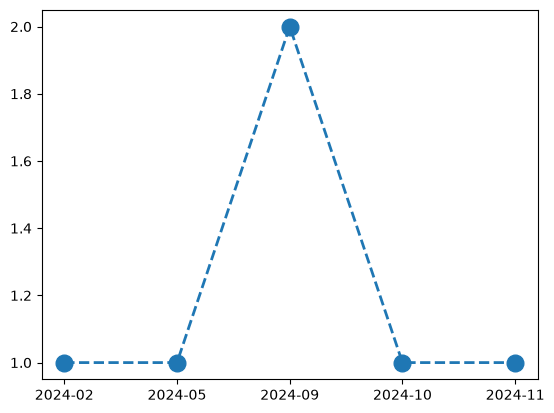

In [104]:
#Now we will visualize the churn trend
#plot function is used to plot data in x and y axis
plt.plot(churn_trend.index.astype(str), churn_trend.values, marker='o', linestyle='dashed', linewidth=2, markersize=12)
#index.astype is used to select the index than we want to display in the x-axis as index in string value
#churn_trend.values is used to represent the values of that column in y-axis

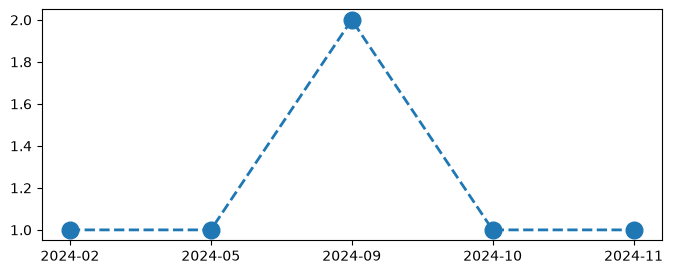

In [103]:
#.figure is used to change the size of the graph
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, marker='o', linestyle='dashed', linewidth=2, markersize=12)

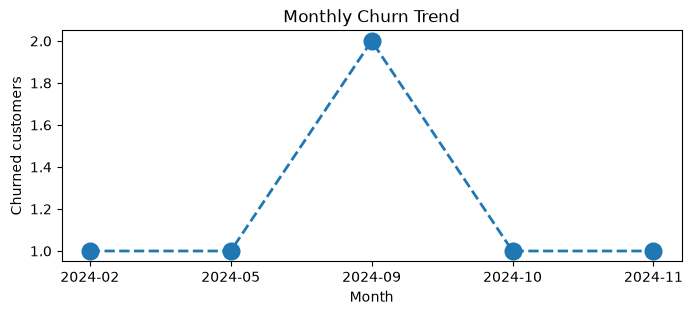

In [107]:
#Now we will add the tile
plt.figure(figsize=(8,3))

plt.plot(churn_trend.index.astype(str), churn_trend.values, marker='o', linestyle='dashed', linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned customers')
plt.show()

In [108]:
#4.2 Churn by Plan Type
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk,cancellation_month
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2027.0,low,NaT
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high,2024-09
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1412.0,low,NaT
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2702.0,low,NaT
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high,2024-02


In [109]:
df_visual.groupby('plan_type')['churn_flag'].mean()

plan_type
Basic       0.600000
Premium     0.142857
Standard    0.222222
Name: churn_flag, dtype: float64

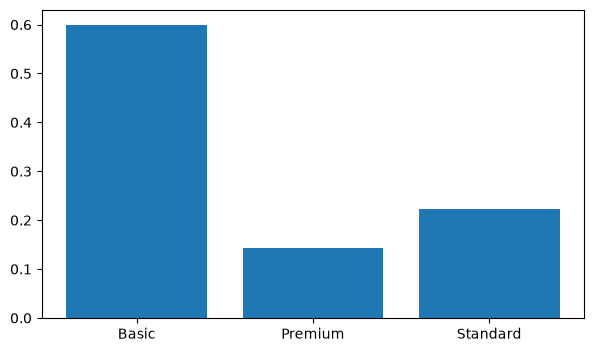

In [110]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

plt.figure(figsize = (7,4))

plt.bar(churn_plan.index, churn_plan.values)
plt.show()

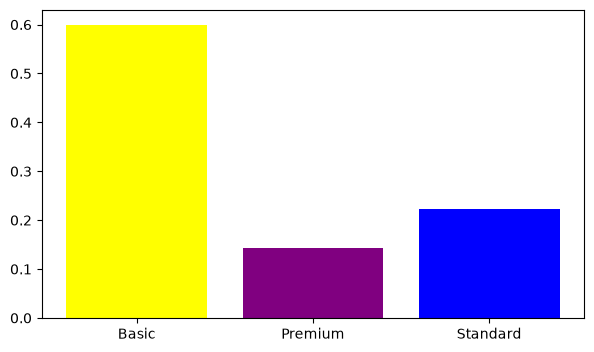

In [111]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = ['yellow', 'purple', 'blue']

plt.figure(figsize = (7,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

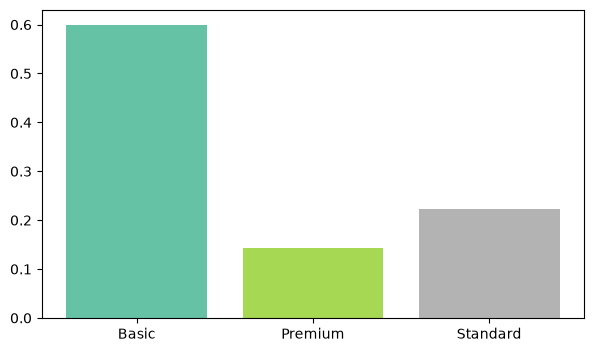

In [114]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))  #here we are randomly selecting the colors of the bar according to the length of the category of churn_paln

plt.figure(figsize = (7,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

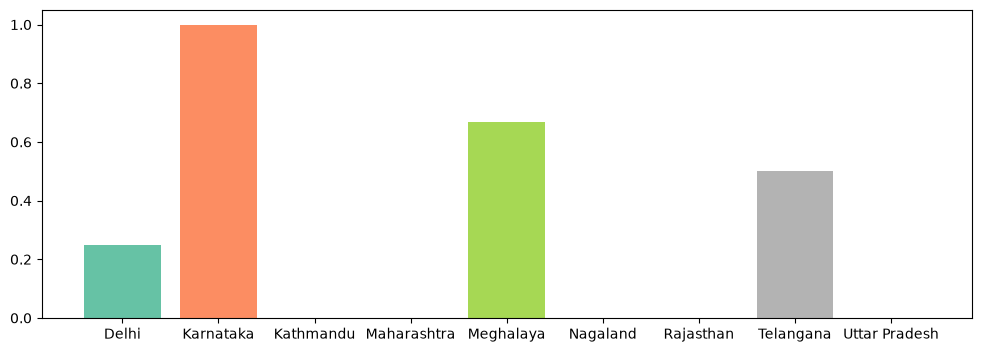

In [116]:
#4.3 Churn by States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))  #here we are randomly selecting the colors of the bar according to the length of the category of churn_paln

plt.figure(figsize = (12,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

# Visulization by Seaborne

In [117]:
#encoding - convert str to numeric so that we can find the correlation between features
df_visual.columns


Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [119]:
#these are the columns in which we want to find the correlation using the heatmap
#so we can see that the columns contain str values so to use the heatmap we need to convert/encode the str values to numeric
df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [120]:
#Now we will encode the selected columns for the heatmap 
df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]

categorical_cols = ['plan_type','contract_type','churn_risk']  #in this we will keep only the categorical data or the str data

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes   #here we have used a loop that picks one columns at a time from the categorical_cols
                                                                     #then we take that columns in df_encoded as we code them into numeric values according to the number of category present in that column

C:\Users\AMIT KUMAR\AppData\Local\Temp\ipykernel_24620\3022079551.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = df_encoded[col].astype('category').cat.codes   #here we have used a loop that picks one columns at a time from the categorical_cols
C:\Users\AMIT KUMAR\AppData\Local\Temp\ipykernel_24620\3022079551.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = df_encoded[col].astype('category').cat.codes   #here we have used a loop that picks one columns at a time fr

In [123]:
#Above that is not an error its just warrning that we have altered the data
df_encoded.head()    #as we can see that now the str values had been converted into numeric values

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

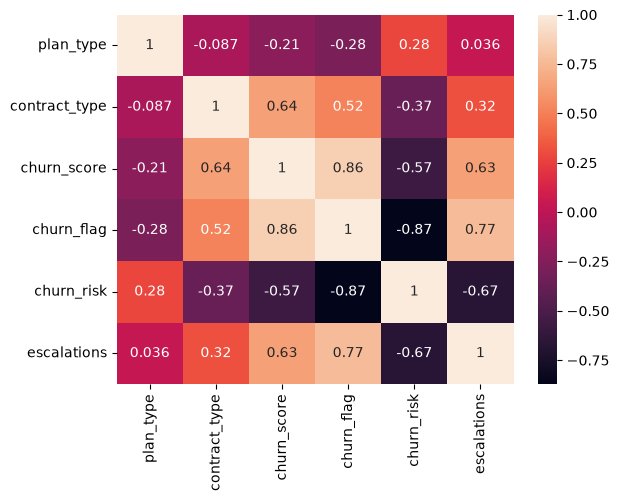

In [124]:
#1 Heatmap (correlation matrix) we can use this only in numeric values

sns.heatmap(df_encoded.corr(), annot = True)

In [125]:
#The above encoding by the sytem is not correct because we can see some errors
#1 the system has encode the churn risk (high, low, medium) alphabateical wise i.e., high = 0, low = 1, medium = 2, as h->l->m
#so baically when creating the heatmap the system gives more importance to 2 then 1 then 0 but for us the important data is the high value
#similarly happened with the contract_type col(Annually, Monthly) as A comes first so Annually->0 Monthlu->1 but for us Annually customers are important
#So now we will use a different approach for encoding as the previous encoding was not based on priority

In [126]:
df_visual['plan_type'].unique()

array(['Standard', 'Premium', 'Basic'], dtype=object)

In [127]:
df_visual['contract_type'].unique()

array(['Annual', 'Monthly'], dtype=object)

In [128]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'med'], dtype=object)

In [130]:
import warnings
warnings.filterwarnings("ignore")

In [132]:
#Correct encoding - based on priority
df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]

order_mappings = {
    'plan_type' : ['Basic','Standard','Premium'],
    'contract_type' : ['Monthly','Annual'],
    'churn_risk' : ['low','med','high']
    }


for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories = order, ordered = True).codes

In [133]:
#So in the above code we have used the dictionary to encode the values based on priority
#in that the key we have kept the columns and in values the order in which the priority should be given
#then we have used the pd.Categorical function to order the values according to the given ordered then codes

In [134]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

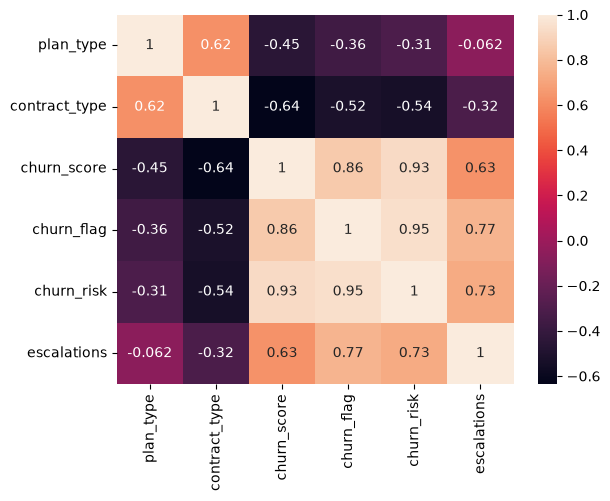

In [135]:
#1 Heatmap (correlation matrix) we can use this only in numeric values

sns.heatmap(df_encoded.corr(), annot = True)

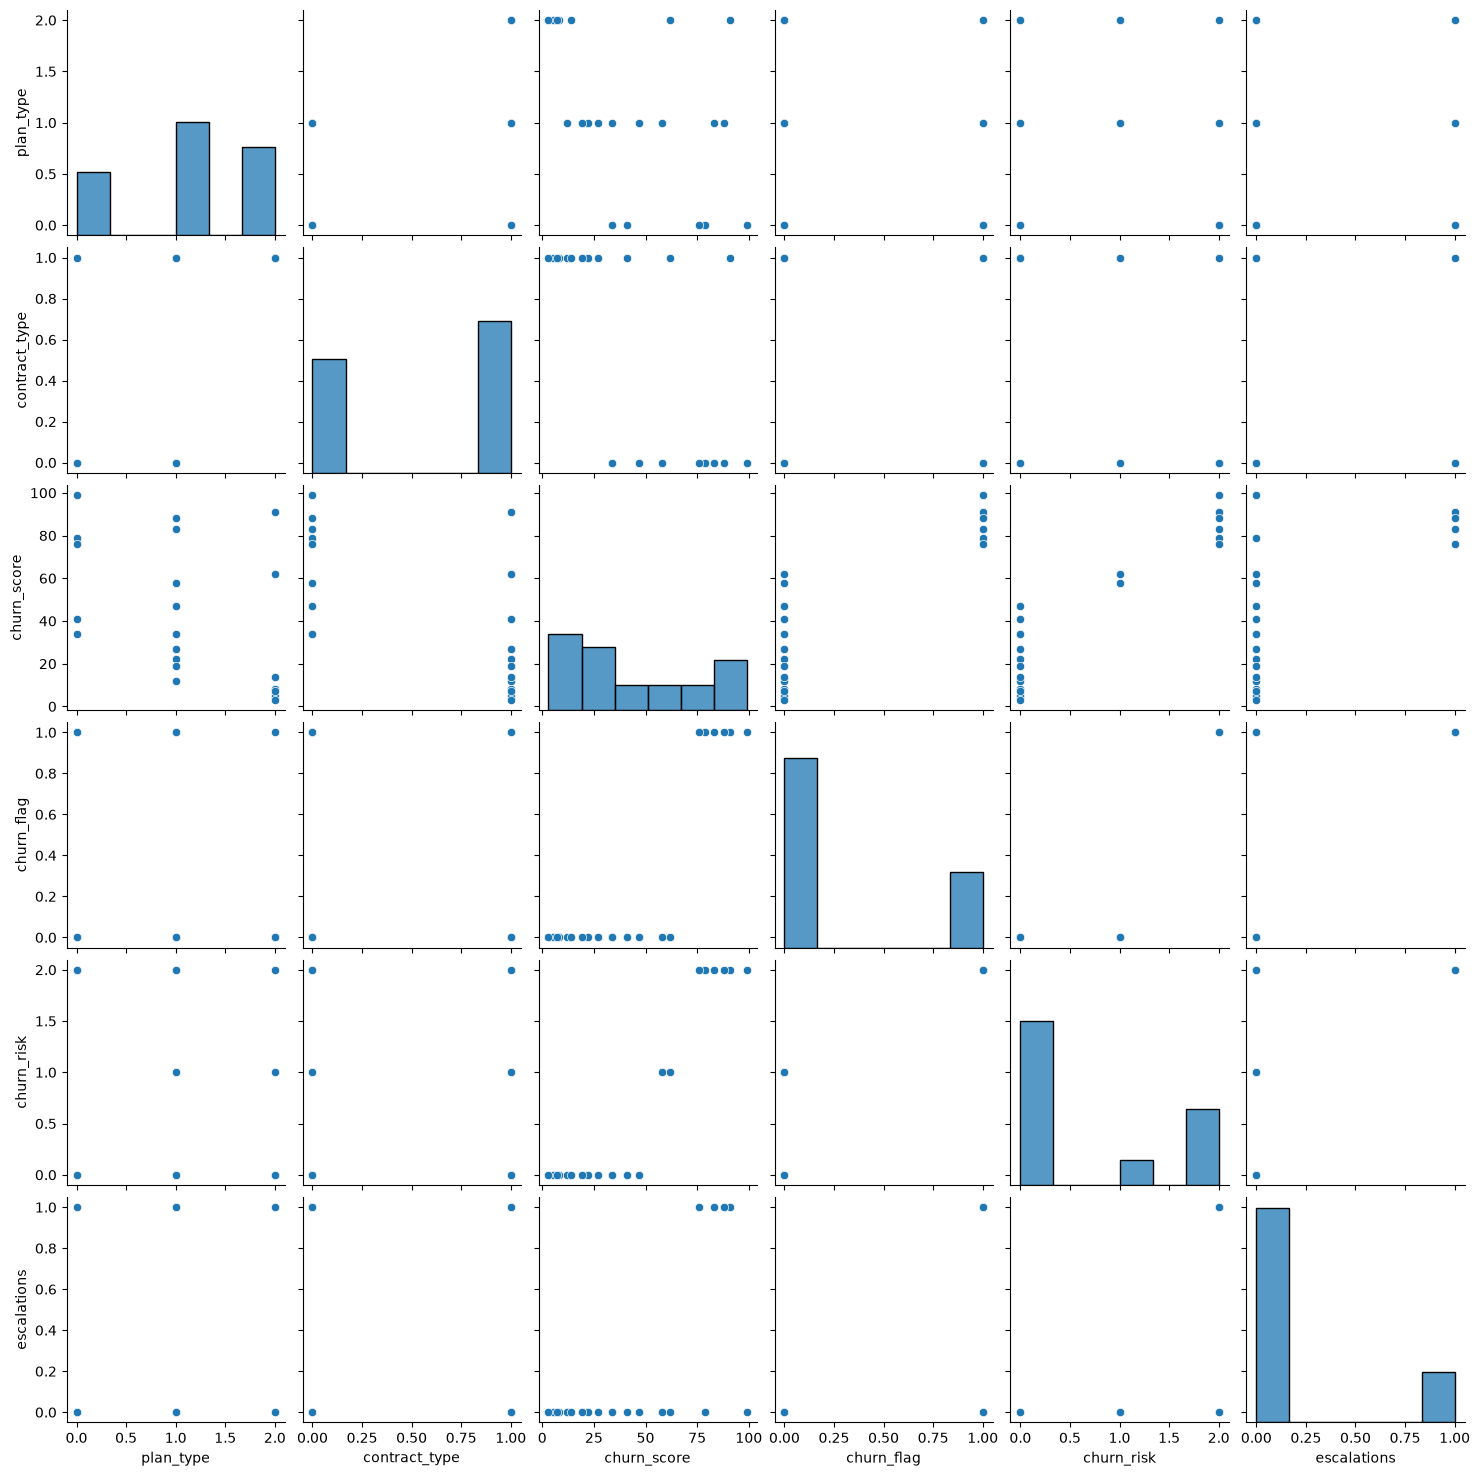

In [137]:
# 2 pairplot - relationship in a dataset

sns.pairplot(df_encoded)

In [138]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

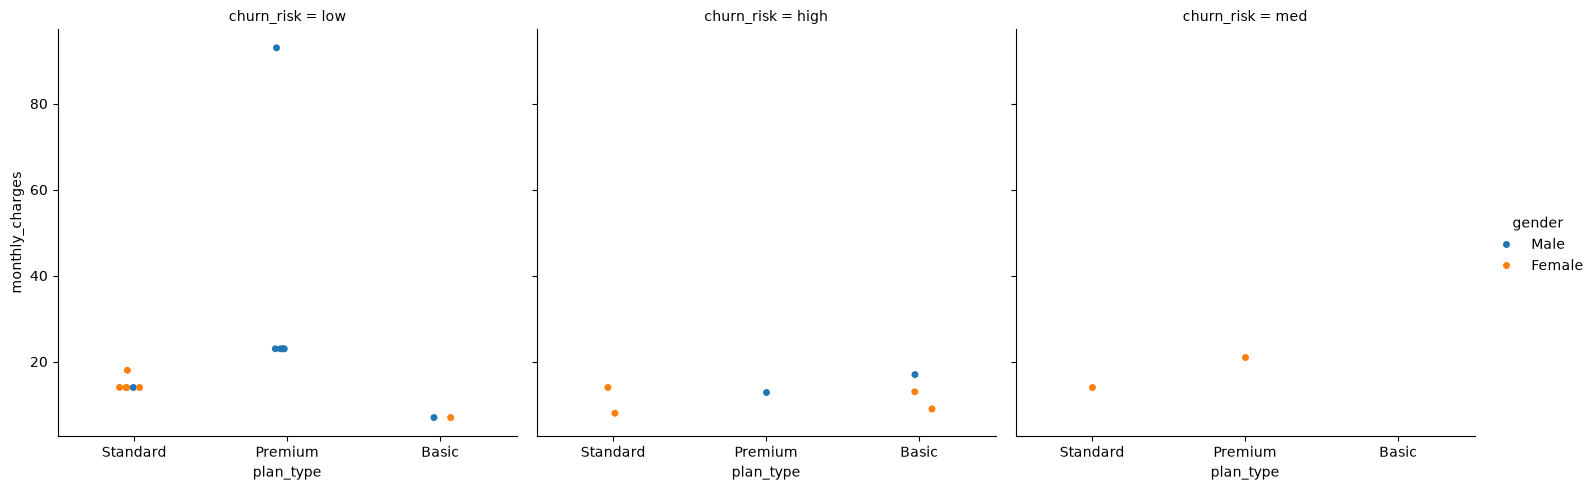

In [139]:
#3 catplt/Facegrid [plot] - multiple dimension comparison
#we can plot different categories of data in this plot (multiple columns)
sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

# Pivot Tables in Python

In [140]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [142]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [143]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [144]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values= ['monthly_charges','customerid','churn_flag'], 
    aggfunc= {
        'monthly_charges': 'sum',
        'customerid': 'nunique',
        'churn_flag': 'mean'
    }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


# Working with SQL in Python (pandas)

In [145]:
#create a db in sql
conn = sqlite3.connect('test_database.sqlite')

#table details
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

# commit and save
conn.commit()

In [146]:
#insert data

cursor = conn.cursor()

#write sql query to insert records in sql table
cursor.execute(
    """
        INSERT INTO users VALUES
            ('Madhav','India',5000),
            ('Rishabh','Germany',4500),
            ('Vishakha','India',4000)
    """
)
#commit and save
conn.commit()

print("Data inserted succesfully")

Data inserted succesfully


In [147]:
#check inserted data in table
conn = sqlite3.connect('test_database.sqlite')

query = """SELECT * FROM users"""

df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budget
0,Madhav,India,5000
1,Rishabh,Germany,4500
2,Vishakha,India,4000


In [148]:
# aggregation
query = """
        SELECT country, sum(budget) as total_budget
        FROM users
        GROUP BY country
"""

df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,4500
1,India,9000


In [149]:
#always close the conn with db once the task is over
conn.close()